# Funding Regime vs L/S Basket & BTCDOM

Role: Senior Quantitative Analyst

Hypothesis (PM): **There are more positive outliers for an Alt-Short strategy (Long Majors / Short Alts) in negative, weak, or low funding environments.**

This notebook:
- Ingests MSM funding timeseries and BTCDOM (Binance & reconstructed) index levels
- Aligns BTCDOM forward weekly returns to the MSM decision-to-next-date windows
- Runs OLS regressions of returns vs funding
- Performs a regime / outlier analysis on the L/S basket and BTCDOM returns
- Produces visual diagnostics (scatter + regression lines, regime boxplots) to evaluate the hypothesis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from pathlib import Path

sns.set(style="whitegrid")

# In notebooks, __file__ may not be defined; fall back to CWD
try:
    BASE_DIR = Path(__file__).resolve().parents[1]
except NameError:
    # Assume notebook lives in /notebooks under repo root
    BASE_DIR = Path.cwd().resolve().parents[0]

# Paths (assumption: use latest full MSM funding run and canonical BTCDOM sources)
MSM_TIMESERIES_PATH = BASE_DIR / "reports" / "msm_funding_v0" / "msm_v0_full_2023_2026" / "msm_timeseries.csv"
# Note: We no longer rely on legacy scratchpad BTCDOM sources.
# Binance BTCDOM is currently unused in the alpha matrix; reconstructed BTCDOM is the production source.
BINANCE_BTCDOM_PATH = None
RECON_BTCDOM_PATH = BASE_DIR / "data" / "curated" / "data_lake" / "btcdom_reconstructed.csv"  # production reconstructed BTCDOM

MSM_TIMESERIES_PATH, BINANCE_BTCDOM_PATH, RECON_BTCDOM_PATH

(WindowsPath('C:/Users/Admin/Documents/Cursor/reports/msm_funding_v0/msm_v0_full_2023_2026/msm_timeseries.csv'),
 None,
 WindowsPath('C:/Users/Admin/Documents/Cursor/data/curated/data_lake/btcdom_reconstructed.csv'))

In [2]:
def compute_window_return(price_df: pd.DataFrame,
                          date_col: str,
                          value_col: str,
                          windows_df: pd.DataFrame,
                          window_start_col: str = "decision_date",
                          window_end_col: str = "next_date",
                          out_col: str = "ret") -> pd.Series:
    """Compute exact-window forward returns for each [decision_date, next_date] pair.

    Uses exact matching on the boundary dates (no interpolation). If either boundary
    is missing in the price series, the return is NaN for that window.
    """
    df = price_df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.set_index(date_col).sort_index()

    rets = []
    for _, row in windows_df[[window_start_col, window_end_col]].iterrows():
        start = row[window_start_col]
        end = row[window_end_col]
        try:
            p0 = df.loc[start, value_col]
            p1 = df.loc[end, value_col]
            rets.append((p1 / p0) - 1.0)
        except KeyError:
            rets.append(np.nan)

    return pd.Series(rets, index=windows_df.index, name=out_col)

In [3]:
# 1. Data Ingestion & Alignment

# MSM funding + L/S basket timeseries
msm = pd.read_csv(
    MSM_TIMESERIES_PATH,
    parse_dates=["decision_date", "next_date"],
)

msm = msm[["decision_date", "next_date", "F_tk", "y"]].copy()
msm = msm.sort_values("decision_date").reset_index(drop=True)

# Bounds gate: load reconstructed BTCDOM from curated data lake and enforce sensible bounds
recon_btcd = pd.read_csv(
    RECON_BTCDOM_PATH,
    parse_dates=["date"],
).sort_values("date")

recon_desc = recon_btcd["reconstructed_index_value"].describe()
print("\nReconstructed BTCDOM describe():")
print(recon_desc)
assert recon_desc["max"] < 6000, "Reconstructed BTCDOM index has implausible max value; aborting."

# Exact daily index levels to align with MSM decision/next windows
recon_levels = recon_btcd[["date", "reconstructed_index_value"]].rename(
    columns={"reconstructed_index_value": "btcd_index"}
)

# Merge exact index level on decision_date and next_date
msm = msm.merge(
    recon_levels.rename(columns={"date": "decision_date", "btcd_index": "btcd_index_decision"}),
    on="decision_date",
    how="left",
)

msm = msm.merge(
    recon_levels.rename(columns={"date": "next_date", "btcd_index": "btcd_index_next"}),
    on="next_date",
    how="left",
)

# Weekly reconstructed BTCDOM return over decision_date -> next_date
msm["ret_btcdom_recon"] = msm["btcd_index_next"] / msm["btcd_index_decision"] - 1.0

# Trailing 7-day reconstructed BTCDOM return leading into decision_date (for trend)
msm["trailing_date"] = msm["decision_date"] - pd.Timedelta(days=7)
msm = msm.merge(
    recon_levels.rename(columns={"date": "trailing_date", "btcd_index": "btcd_index_trailing"}),
    on="trailing_date",
    how="left",
)
msm["ret_btcdom_trailing"] = msm["btcd_index_decision"] / msm["btcd_index_trailing"] - 1.0

msm.head()


Reconstructed BTCDOM describe():
count     575.000000
mean     3740.553184
std       706.657428
min      2448.025296
25%      3005.368351
50%      3847.105224
75%      4260.320072
max      5053.738198
Name: reconstructed_index_value, dtype: float64


,decision_date,next_date,F_tk,y,btcd_index_decision,btcd_index_next,ret_btcdom_recon,trailing_date,btcd_index_trailing,ret_btcdom_trailing
0,2024-02-05,2024-02-12,0.007273,0.016899,NaN,NaN,NaN,2024-01-29,NaN,NaN
1,2024-02-12,2024-02-19,-0.001252,-0.028450,NaN,NaN,NaN,2024-02-05,NaN,NaN
2,2024-02-19,2024-02-26,0.021987,-0.010616,NaN,NaN,NaN,2024-02-12,NaN,NaN
3,2024-02-26,2024-03-04,0.025864,0.046905,NaN,NaN,NaN,2024-02-19,NaN,NaN
4,2024-03-04,2024-03-11,0.055629,0.022523,NaN,NaN,NaN,2024-02-26,NaN,NaN


In [4]:
# Point-in-time: 30d SMA for trend + 52w rolling funding regime
recon_btcd["sma_30"] = recon_btcd["reconstructed_index_value"].rolling(window=30, min_periods=30).mean()
sma_df = recon_btcd[["date", "sma_30"]].rename(columns={"date": "decision_date", "sma_30": "sma_30_decision"})
msm = msm.merge(sma_df, on="decision_date", how="left")

msm = msm.sort_values("decision_date").reset_index(drop=True)
msm["funding_pct_rank"] = msm["F_tk"].rolling(window=52, min_periods=26).apply(
    lambda x: pd.Series(x).rank(pct=True).iloc[-1], raw=False
)
msm["funding_regime"] = pd.cut(
    msm["funding_pct_rank"],
    bins=[0.0, 0.25, 0.50, 0.75, 1.0],
    labels=["Q1: Negative/Low", "Q2: Weak", "Q3: Neutral", "Q4: High"],
    include_lowest=True,
)

In [5]:
# 2. Regression Analysis (OLS): Funding vs Returns

# Filter to rows where all key series are present (Binance no longer required)
reg_df = msm.dropna(subset=["F_tk", "y", "ret_btcdom_recon"]).copy()

print(f"Total observations for regression: {len(reg_df)}")


def run_ols(y_col: str, x_col: str, label: str):
    df = reg_df[[x_col, y_col]].dropna().copy()
    X = sm.add_constant(df[x_col])
    model = sm.OLS(df[y_col], X).fit()

    r2 = model.rsquared
    beta = model.params[x_col]
    pval = model.pvalues[x_col]

    print(f"\n=== OLS: {label} vs Funding (F_tk) ===")
    print(f"n = {len(df)}")
    print(f"R-squared: {r2:.4f}")
    print(f"Beta (Funding -> {label}): {beta:.6f}")
    print(f"p-value (beta): {pval:.6g}")

    return model


model_ls = run_ols(y_col="y", x_col="F_tk", label="L/S Basket Return")
model_btcdom_recon = run_ols(y_col="ret_btcdom_recon", x_col="F_tk", label="Reconstructed BTCDOM Weekly Return")

Total observations for regression: 80

=== OLS: L/S Basket Return vs Funding (F_tk) ===
n = 80
R-squared: 0.0003
Beta (Funding -> L/S Basket Return): 0.172909
p-value (beta): 0.869678

=== OLS: Reconstructed BTCDOM Weekly Return vs Funding (F_tk) ===
n = 80
R-squared: 0.0020
Beta (Funding -> Reconstructed BTCDOM Weekly Return): 0.281100
p-value (beta): 0.694287


In [6]:
# 3. Regime & Outlier Analysis

# Define funding regimes using quartiles of F_tk
analysis_df = reg_df.copy()

# 4 quartiles: bottom = Negative/Low, top = High
analysis_df["funding_regime"] = pd.qcut(
    analysis_df["F_tk"],
    q=4,
    labels=["Q1: Negative/Low", "Q2: Weak", "Q3: Neutral", "Q4: High"],
)


def regime_stats(df: pd.DataFrame, ret_col: str, regime_col: str = "funding_regime") -> pd.DataFrame:
    g = df.groupby(regime_col)[ret_col]
    stats = g.agg(["count", "mean", "median", "std"]).rename(columns={"std": "std_dev"})
    stats["skew"] = g.skew()
    stats["p90"] = g.quantile(0.90)
    stats["p95"] = g.quantile(0.95)
    return stats


ls_stats = regime_stats(analysis_df, "y")
recon_stats = regime_stats(analysis_df, "ret_btcdom_recon")

print("\n=== L/S Basket Return by Funding Regime (Quartiles) ===")
print(ls_stats)

print("\n=== Reconstructed BTCDOM Weekly Return by Funding Regime (Quartiles) ===")
print(recon_stats)


=== L/S Basket Return by Funding Regime (Quartiles) ===
                  count      mean    median   std_dev      skew       p90  \
funding_regime                                                              
Q1: Negative/Low     20  0.001121 -0.007174  0.035604  1.082112  0.041708   
Q2: Weak             20 -0.010357 -0.008329  0.051311  0.273719  0.032925   
Q3: Neutral          20  0.012114  0.027824  0.067634 -1.259370  0.075668   
Q4: High             20  0.006310  0.030321  0.083505 -0.482052  0.096177   

                       p95  
funding_regime              
Q1: Negative/Low  0.053151  
Q2: Weak          0.042720  
Q3: Neutral       0.081394  
Q4: High          0.103176  

=== Reconstructed BTCDOM Weekly Return by Funding Regime (Quartiles) ===
                  count      mean    median   std_dev      skew       p90  \
funding_regime                                                              
Q1: Negative/Low     20  0.005984  0.000004  0.024277  0.193771  0.039890   
Q

C:\Users\Admin\AppData\Local\Temp\ipykernel_48028\3264787454.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(regime_col)[ret_col]
C:\Users\Admin\AppData\Local\Temp\ipykernel_48028\3264787454.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby(regime_col)[ret_col]


<Figure size 1800x500 with 0 Axes>

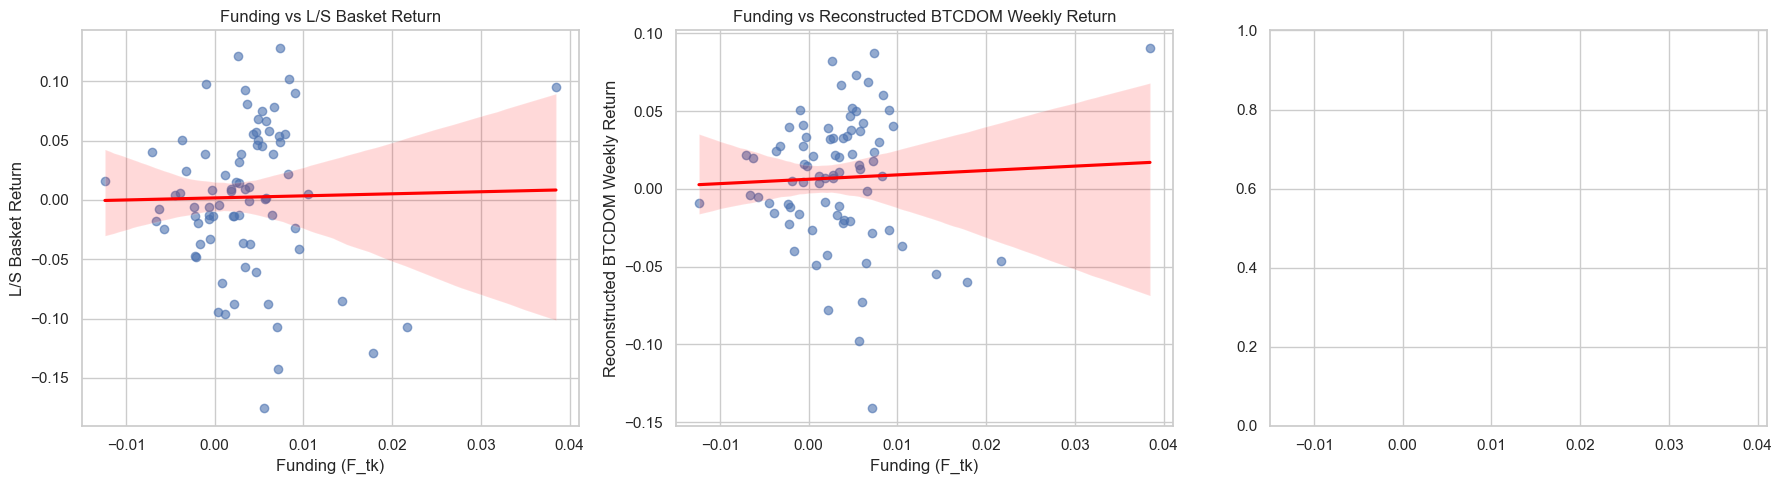

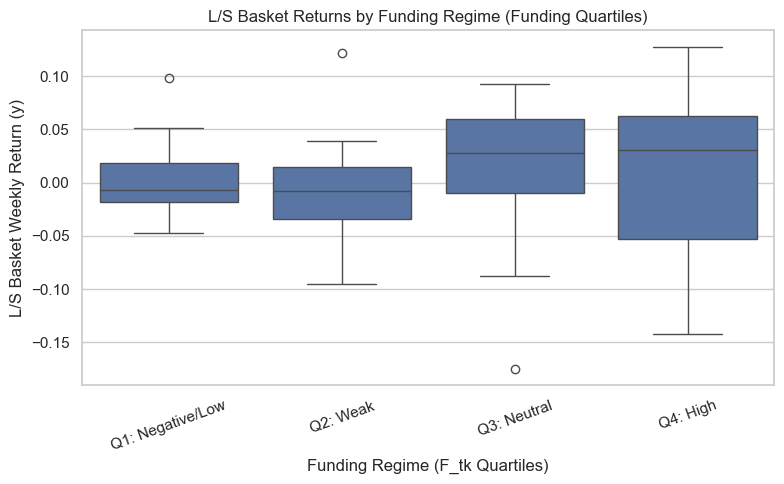

In [7]:
# 4. Visualizations

plt.figure(figsize=(18, 5))
axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True)[1]

targets = [
    ("y", "L/S Basket Return"),
    ("ret_btcdom_recon", "Reconstructed BTCDOM Weekly Return"),
]

for ax, (col, label) in zip(axs, targets):
    sns.regplot(
        data=analysis_df,
        x="F_tk",
        y=col,
        ax=ax,
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"},
    )
    ax.set_title(f"Funding vs {label}")
    ax.set_xlabel("Funding (F_tk)")
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()

# Distribution of L/S basket returns across funding regimes
plt.figure(figsize=(8, 5))
sns.boxplot(data=analysis_df, x="funding_regime", y="y")
plt.title("L/S Basket Returns by Funding Regime (Funding Quartiles)")
plt.xlabel("Funding Regime (F_tk Quartiles)")
plt.ylabel("L/S Basket Weekly Return (y)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [8]:
# 5. 2D Alpha Matrix: Funding Regime x BTCDOM Trend (weekly reconstructed return)

alpha_df = analysis_df.dropna(subset=["ret_btcdom_trailing"]).copy()

# Define BTCDOM_Trend from trailing 7-day reconstructed BTCDOM return
alpha_df["BTCDOM_Trend"] = np.where(alpha_df["ret_btcdom_trailing"] > 0, "Rising", "Falling")

# Ensure BTCDOM_Trend is ordered consistently on the X-axis
alpha_df["BTCDOM_Trend"] = pd.Categorical(
    alpha_df["BTCDOM_Trend"],
    categories=["Rising", "Falling"],
    ordered=True,
)

g2 = alpha_df.groupby(["funding_regime", "BTCDOM_Trend"]) ["y"]

alpha_stats = g2.agg(["count", "mean", "median"]).rename(columns={"mean": "mean_y", "median": "median_y"})
alpha_stats["win_rate"] = g2.apply(lambda s: (s > 0).mean())
alpha_stats["skew"] = g2.skew()

print("\n=== 2D Alpha Matrix: L/S Basket Return by Funding Regime x BTCDOM Trend ===")
print(alpha_stats)


=== 2D Alpha Matrix: L/S Basket Return by Funding Regime x BTCDOM Trend ===
                               count    mean_y  median_y  win_rate      skew
funding_regime   BTCDOM_Trend                                               
Q1: Negative/Low Rising           16 -0.002091 -0.010420  0.375000  1.390986
                 Falling           4  0.013968  0.016363  0.500000 -0.125887
Q2: Weak         Rising           14 -0.011197 -0.013540  0.428571  0.662721
                 Falling           6 -0.008399  0.002148  0.500000 -1.777865
Q3: Neutral      Rising           13  0.024444  0.050910  0.769231 -1.923754
                 Falling           6 -0.003107  0.001287  0.666667  0.375665
Q4: High         Rising            5  0.036608  0.057868  0.800000 -1.664991
                 Falling          15 -0.003789  0.005199  0.533333 -0.328691


C:\Users\Admin\AppData\Local\Temp\ipykernel_48028\2079491261.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g2 = alpha_df.groupby(["funding_regime", "BTCDOM_Trend"]) ["y"]


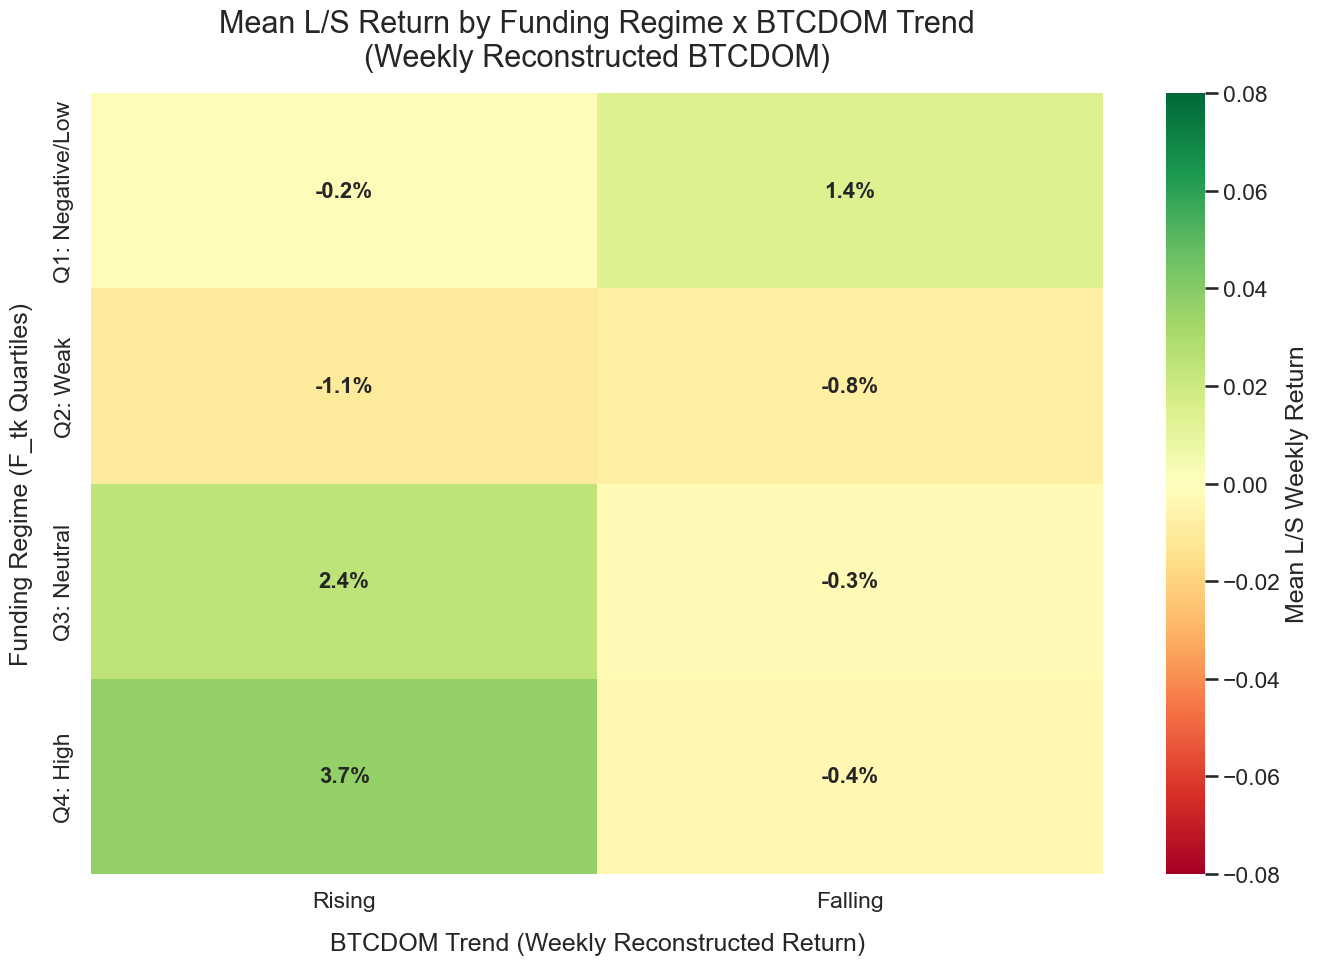

WindowsPath('C:/Users/Admin/Documents/Cursor/notebooks/matrix_ls_basket.png')

In [9]:
# 6. Alpha Matrix Heatmap (Mean L/S Return)

mean_pivot = alpha_stats["mean_y"].unstack("BTCDOM_Trend")

# High-clarity styling for presentation
sns.set_context("talk")
plt.figure(figsize=(14, 10))

ax = sns.heatmap(
    mean_pivot,
    annot=True,
    fmt=".1%",  # show as percentage with one decimal
    cmap="RdYlGn",
    center=0.0,
    vmin=-0.08,
    vmax=0.08,
    annot_kws={"size": 16, "fontweight": "bold"},
    cbar_kws={"label": "Mean L/S Weekly Return"},
)

plt.title(
    "Mean L/S Return by Funding Regime x BTCDOM Trend\n(Weekly Reconstructed BTCDOM)",
    fontsize=22,
    pad=20,
)
ax.set_xlabel("BTCDOM Trend (Weekly Reconstructed Return)", fontsize=18, labelpad=15)
ax.set_ylabel("Funding Regime (F_tk Quartiles)", fontsize=18, labelpad=15)

plt.tight_layout()

ls_heatmap_path = BASE_DIR / "notebooks" / "matrix_ls_basket.png"
plt.savefig(ls_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

ls_heatmap_path

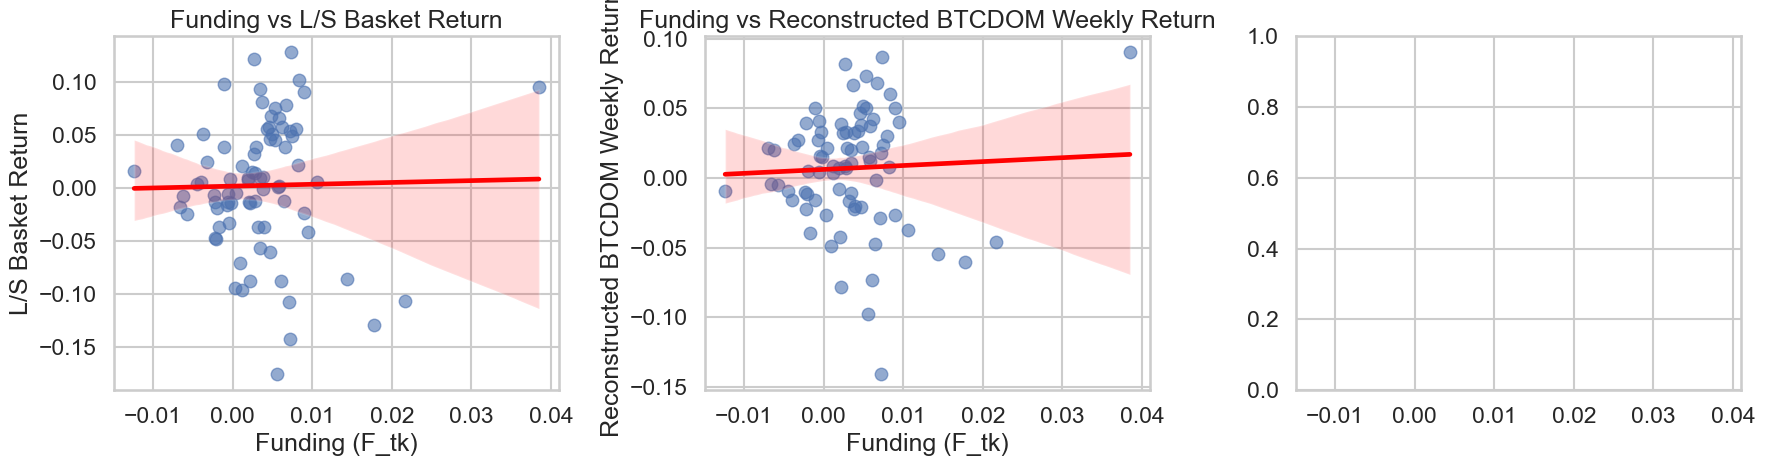

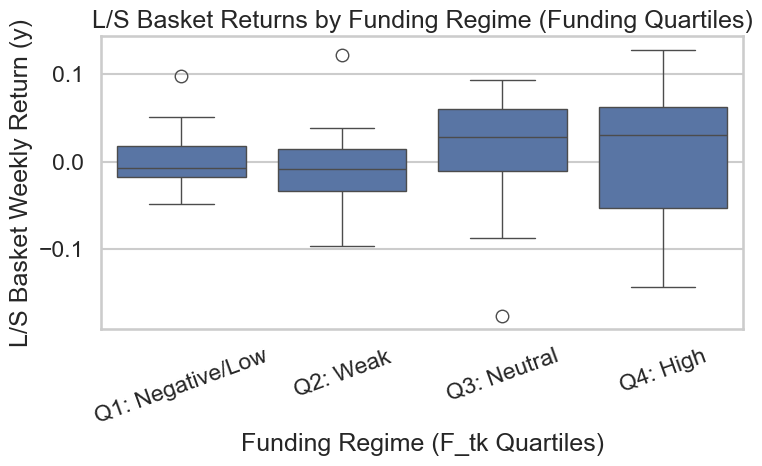

(WindowsPath('C:/Users/Admin/Documents/Cursor/notebooks/funding_scatter.png'),
 WindowsPath('C:/Users/Admin/Documents/Cursor/notebooks/regime_boxplot.png'))

In [10]:
# 7. Export key visuals as PNGs in /notebooks

# Scatter plots: Funding vs returns (1x3 grid)
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

targets = [
    ("y", "L/S Basket Return"),
    ("ret_btcdom_recon", "Reconstructed BTCDOM Weekly Return"),
]

for ax, (col, label) in zip(axs, targets):
    sns.regplot(
        data=analysis_df,
        x="F_tk",
        y=col,
        ax=ax,
        scatter_kws={"alpha": 0.6},
        line_kws={"color": "red"},
    )
    ax.set_title(f"Funding vs {label}")
    ax.set_xlabel("Funding (F_tk)")
    ax.set_ylabel(label)

plt.tight_layout()
scatter_path = BASE_DIR / "notebooks" / "funding_scatter.png"
fig.savefig(scatter_path, dpi=150, bbox_inches="tight")
plt.show()

# Boxplot: L/S basket returns across funding regimes
fig2, ax2 = plt.subplots(figsize=(8, 5))
sns.boxplot(data=analysis_df, x="funding_regime", y="y", ax=ax2)
ax2.set_title("L/S Basket Returns by Funding Regime (Funding Quartiles)")
ax2.set_xlabel("Funding Regime (F_tk Quartiles)")
ax2.set_ylabel("L/S Basket Weekly Return (y)")
plt.xticks(rotation=20)
plt.tight_layout()
boxplot_path = BASE_DIR / "notebooks" / "regime_boxplot.png"
fig2.savefig(boxplot_path, dpi=150, bbox_inches="tight")
plt.show()

scatter_path, boxplot_path

In [11]:
# 8. Debugging Binance BTCDOM Weekly Return Outliers (deprecated)
print("\n[Debug] Binance BTCDOM forensics deprecated: using reconstructed BTCDOM only.")


[Debug] Binance BTCDOM forensics deprecated: using reconstructed BTCDOM only.


In [12]:
# 9. Macro Index Behavior Across Funding Regime x BTCDOM Trend

# Reload MSM cleanly for macro index analysis
msm_macro = pd.read_csv(
    MSM_TIMESERIES_PATH,
    parse_dates=["decision_date", "next_date"],
)
msm_macro = msm_macro[["decision_date", "next_date", "F_tk", "y"]].copy()
# Ensure datetime64[ns] for consistent merges
msm_macro["decision_date"] = pd.to_datetime(msm_macro["decision_date"])
msm_macro["next_date"] = pd.to_datetime(msm_macro["next_date"])
msm_macro = msm_macro.sort_values("decision_date").reset_index(drop=True)

# Load reconstructed BTCDOM (curated lake) and compute weekly return
recon_macro = pd.read_csv(
    RECON_BTCDOM_PATH,
    parse_dates=["date"],
).sort_values("date")

recon_levels_macro = recon_macro[["date", "reconstructed_index_value"]].rename(
    columns={"reconstructed_index_value": "recon_index"}
)

msm_macro = msm_macro.merge(
    recon_levels_macro.rename(columns={"date": "decision_date", "recon_index": "recon_decision"}),
    on="decision_date",
    how="left",
)

msm_macro = msm_macro.merge(
    recon_levels_macro.rename(columns={"date": "next_date", "recon_index": "recon_next"}),
    on="next_date",
    how="left",
)

msm_macro["ret_btcdom_recon"] = msm_macro["recon_next"] / msm_macro["recon_decision"] - 1.0

# Load Binance BTCDOM from curated lake and compute weekly return
BINANCE_CURATED_PATH = BASE_DIR / "data" / "curated" / "data_lake" / "binance_btcdom.csv"

binance_macro = pd.read_csv(BINANCE_CURATED_PATH, parse_dates=["timestamp"])
# Ensure Binance timestamps are timezone-naive to match MSM
_ts = binance_macro["timestamp"]
if getattr(_ts.dt, "tz", None) is not None:
    binance_macro["timestamp"] = _ts.dt.tz_convert(None)
else:
    binance_macro["timestamp"] = _ts
binance_macro["date"] = binance_macro["timestamp"].dt.normalize()  # keep as datetime64[ns] to match MSM

binance_levels_macro = binance_macro[["date", "close"]].rename(
    columns={"close": "binance_index"}
)

msm_macro = msm_macro.merge(
    binance_levels_macro.rename(columns={"date": "decision_date", "binance_index": "binance_decision"}),
    on="decision_date",
    how="left",
)

msm_macro = msm_macro.merge(
    binance_levels_macro.rename(columns={"date": "next_date", "binance_index": "binance_next"}),
    on="next_date",
    how="left",
)

msm_macro["ret_btcdom_binance"] = msm_macro["binance_next"] / msm_macro["binance_decision"] - 1.0

# Drop rows with missing key data
macro_df = msm_macro.dropna(subset=["F_tk", "ret_btcdom_recon", "ret_btcdom_binance"]).copy()

# Funding Regime: quartiles of F_tk
macro_df["funding_regime"] = pd.qcut(
    macro_df["F_tk"],
    q=4,
    labels=["Q1: Negative/Low", "Q2: Weak", "Q3: Neutral", "Q4: High"],
)

# BTCDOM Trend from reconstructed weekly return
macro_df["BTCDOM_Trend"] = np.where(macro_df["ret_btcdom_recon"] > 0, "Rising", "Falling")
macro_df["BTCDOM_Trend"] = pd.Categorical(
    macro_df["BTCDOM_Trend"],
    categories=["Rising", "Falling"],
    ordered=True,
)

# Table 1: Reconstructed BTCDOM behavior
g_recon = macro_df.groupby(["funding_regime", "BTCDOM_Trend"])["ret_btcdom_recon"]

recon_macro_stats = g_recon.agg(["count", "mean", "median"]).rename(
    columns={"mean": "mean_ret", "median": "median_ret"}
)
recon_macro_stats["win_rate"] = g_recon.apply(lambda s: (s > 0).mean())
recon_macro_stats["skew"] = g_recon.skew()

print("\n=== Macro Index Behavior (Reconstructed BTCDOM Return) ===")
print(recon_macro_stats)

# Table 2: Binance BTCDOM behavior
g_binance = macro_df.groupby(["funding_regime", "BTCDOM_Trend"])["ret_btcdom_binance"]

binance_macro_stats = g_binance.agg(["count", "mean", "median"]).rename(
    columns={"mean": "mean_ret", "median": "median_ret"}
)
binance_macro_stats["win_rate"] = g_binance.apply(lambda s: (s > 0).mean())
binance_macro_stats["skew"] = g_binance.skew()

print("\n=== Macro Index Behavior (Binance BTCDOM Return) ===")
print(binance_macro_stats)


=== Macro Index Behavior (Reconstructed BTCDOM Return) ===
                               count  mean_ret  median_ret  win_rate      skew
funding_regime   BTCDOM_Trend                                                 
Q1: Negative/Low Rising           10  0.026266    0.026077       1.0 -0.006175
                 Falling          10 -0.014297   -0.010847       0.0 -1.808113
Q2: Weak         Rising           14  0.023442    0.018554       1.0  1.918077
                 Falling           6 -0.036810   -0.034579       0.0 -0.725133
Q3: Neutral      Rising           14  0.036569    0.035510       1.0  0.433502
                 Falling           6 -0.040634   -0.021442       0.0 -1.113450
Q4: High         Rising           11  0.047177    0.042348       1.0  0.309602
                 Falling           9 -0.049131   -0.046036       0.0 -1.780001

=== Macro Index Behavior (Binance BTCDOM Return) ===
                               count  mean_ret  median_ret  win_rate      skew
funding_regime   

C:\Users\Admin\AppData\Local\Temp\ipykernel_48028\3906200042.py:87: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g_recon = macro_df.groupby(["funding_regime", "BTCDOM_Trend"])["ret_btcdom_recon"]
C:\Users\Admin\AppData\Local\Temp\ipykernel_48028\3906200042.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g_binance = macro_df.groupby(["funding_regime", "BTCDOM_Trend"])["ret_btcdom_binance"]


C:\Users\Admin\AppData\Local\Temp\ipykernel_48028\332489431.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  macro_group = macro_df.groupby(["funding_regime", "BTCDOM_Trend"])


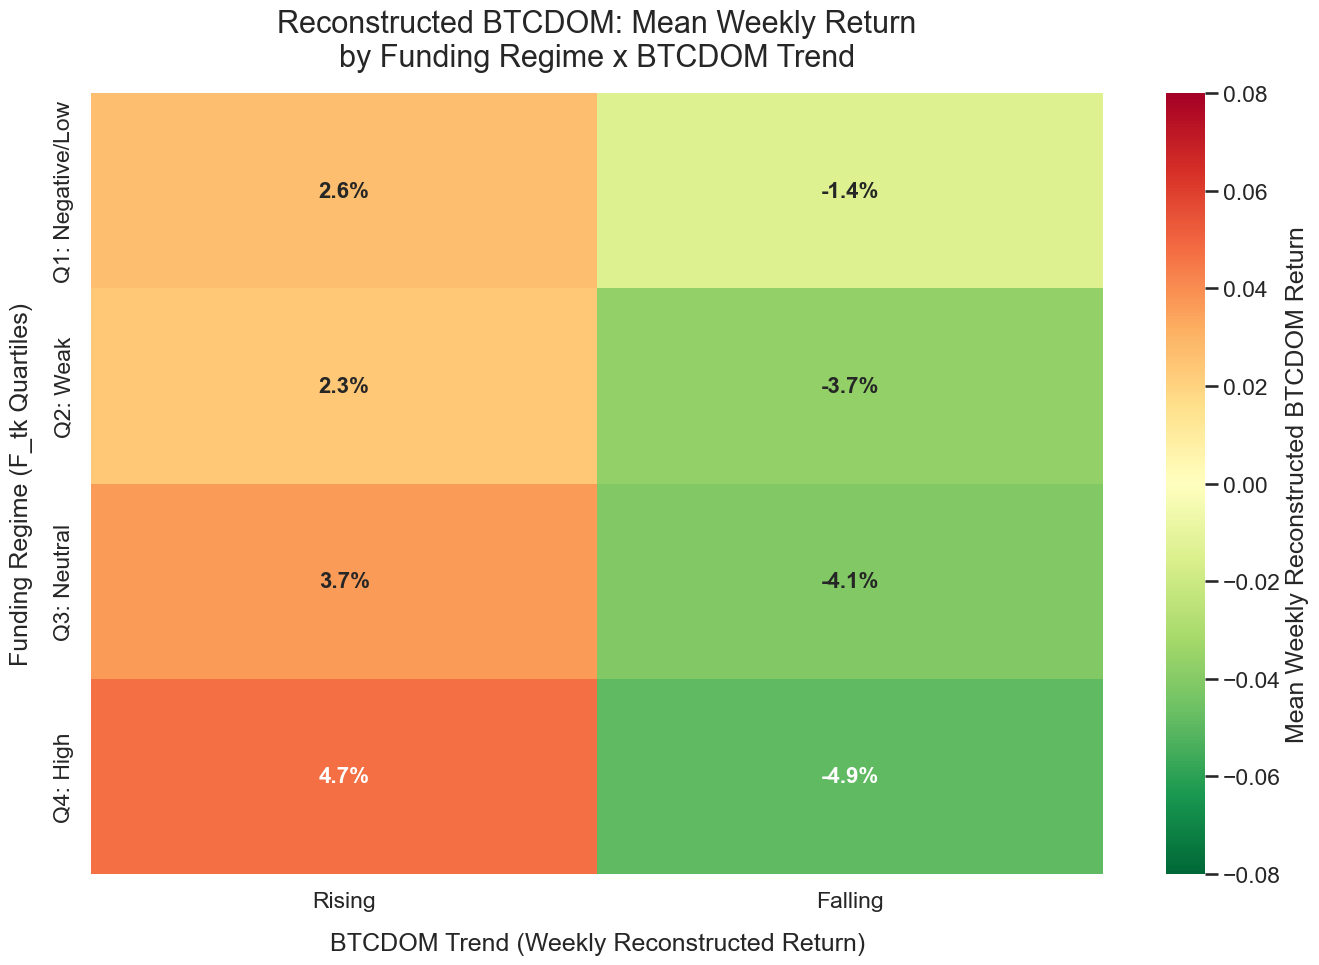

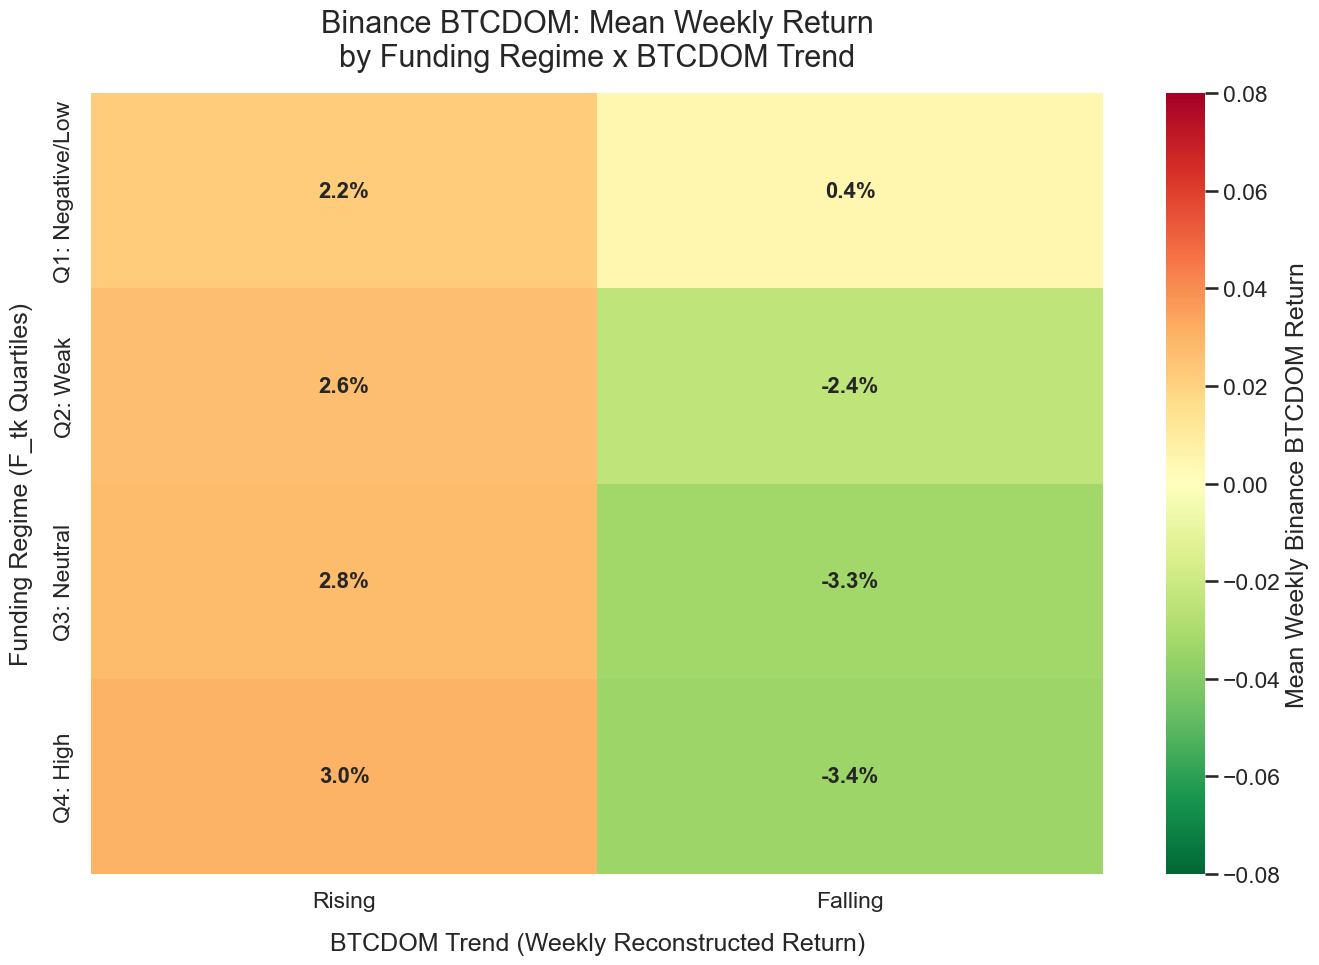

(WindowsPath('C:/Users/Admin/Documents/Cursor/notebooks/matrix_recon_btcdom.png'),
 WindowsPath('C:/Users/Admin/Documents/Cursor/notebooks/matrix_binance_btcdom.png'))

In [13]:
# 10. Heatmaps: Mean BTCDOM Weekly Return Across Regimes

# Recompute stats locally to avoid dependency on previous cells
macro_group = macro_df.groupby(["funding_regime", "BTCDOM_Trend"])

recon_macro_stats = macro_group["ret_btcdom_recon"].agg(["count", "mean", "median"]).rename(
    columns={"mean": "mean_ret", "median": "median_ret"}
)
recon_macro_stats["win_rate"] = macro_group["ret_btcdom_recon"].apply(lambda s: (s > 0).mean())
recon_macro_stats["skew"] = macro_group["ret_btcdom_recon"].skew()

binance_macro_stats = macro_group["ret_btcdom_binance"].agg(["count", "mean", "median"]).rename(
    columns={"mean": "mean_ret", "median": "median_ret"}
)
binance_macro_stats["win_rate"] = macro_group["ret_btcdom_binance"].apply(lambda s: (s > 0).mean())
binance_macro_stats["skew"] = macro_group["ret_btcdom_binance"].skew()

# Pivot tables for heatmaps
recon_mean_pivot = recon_macro_stats["mean_ret"].unstack("BTCDOM_Trend")
binance_mean_pivot = binance_macro_stats["mean_ret"].unstack("BTCDOM_Trend")

# Shared styling parameters
sns.set_context("talk")

# Reconstructed BTCDOM heatmap
plt.figure(figsize=(14, 10))
ax1 = sns.heatmap(
    recon_mean_pivot,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn_r",
    center=0.0,
    vmin=-0.08,
    vmax=0.08,
    annot_kws={"size": 16, "fontweight": "bold"},
    cbar_kws={"label": "Mean Weekly Reconstructed BTCDOM Return"},
)
plt.title(
    "Reconstructed BTCDOM: Mean Weekly Return\nby Funding Regime x BTCDOM Trend",
    fontsize=22,
    pad=20,
)
ax1.set_xlabel("BTCDOM Trend (Weekly Reconstructed Return)", fontsize=18, labelpad=15)
ax1.set_ylabel("Funding Regime (F_tk Quartiles)", fontsize=18, labelpad=15)
plt.tight_layout()

recon_heatmap_path = BASE_DIR / "notebooks" / "matrix_recon_btcdom.png"
plt.savefig(recon_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

# Binance BTCDOM heatmap
plt.figure(figsize=(14, 10))
ax2 = sns.heatmap(
    binance_mean_pivot,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn_r",
    center=0.0,
    vmin=-0.08,
    vmax=0.08,
    annot_kws={"size": 16, "fontweight": "bold"},
    cbar_kws={"label": "Mean Weekly Binance BTCDOM Return"},
)
plt.title(
    "Binance BTCDOM: Mean Weekly Return\nby Funding Regime x BTCDOM Trend",
    fontsize=22,
    pad=20,
)
ax2.set_xlabel("BTCDOM Trend (Weekly Reconstructed Return)", fontsize=18, labelpad=15)
ax2.set_ylabel("Funding Regime (F_tk Quartiles)", fontsize=18, labelpad=15)
plt.tight_layout()

binance_heatmap_path = BASE_DIR / "notebooks" / "matrix_binance_btcdom.png"
plt.savefig(binance_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

recon_heatmap_path, binance_heatmap_path

C:\Users\Admin\AppData\Local\Temp\ipykernel_48028\3668795638.py:93: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  macro_group_tr = macro_tr.groupby(["funding_regime", "BTCDOM_Trend"])


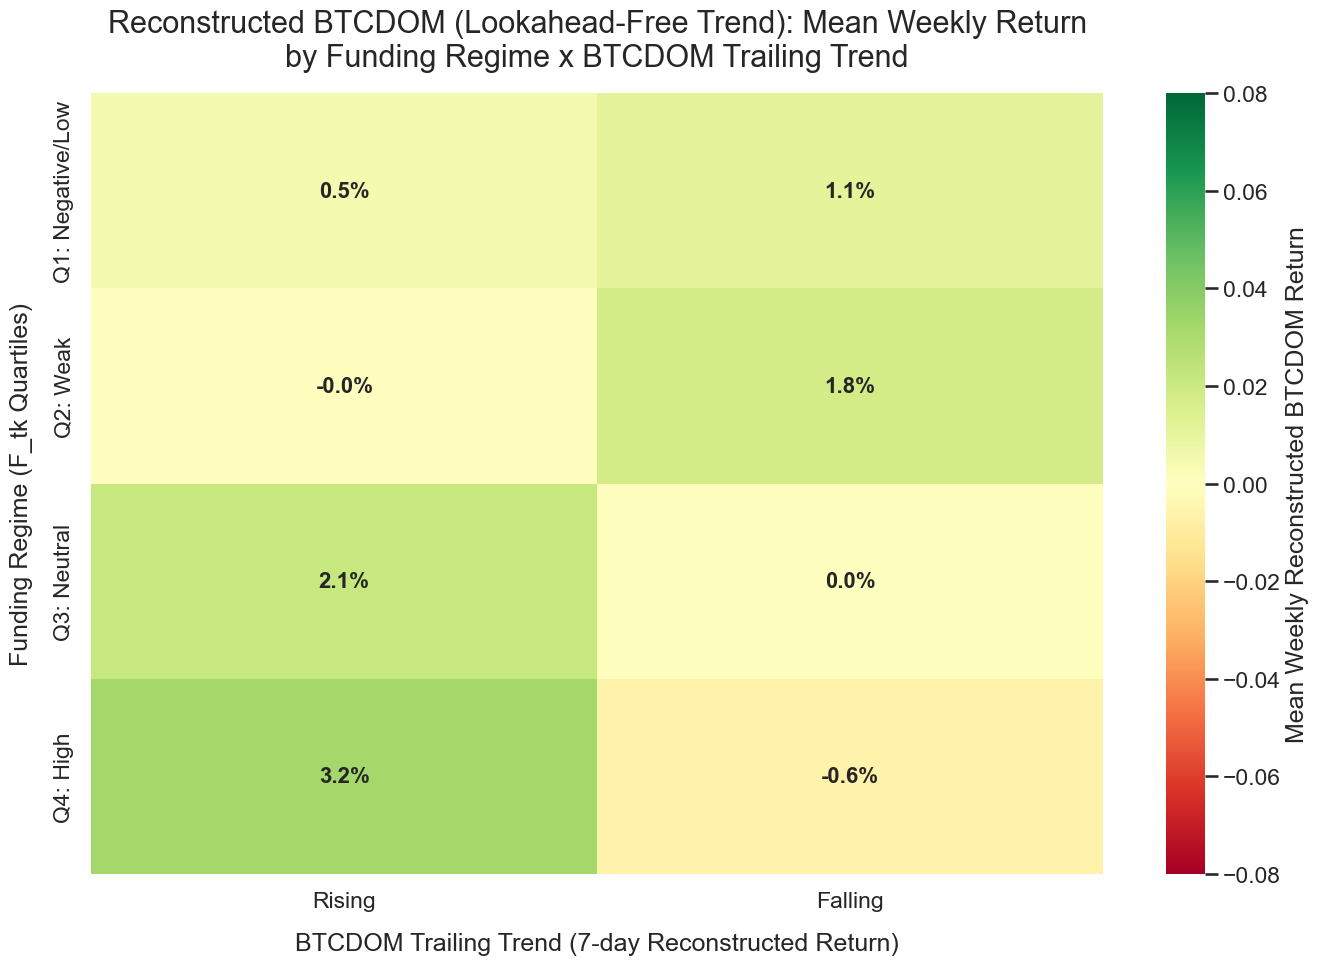

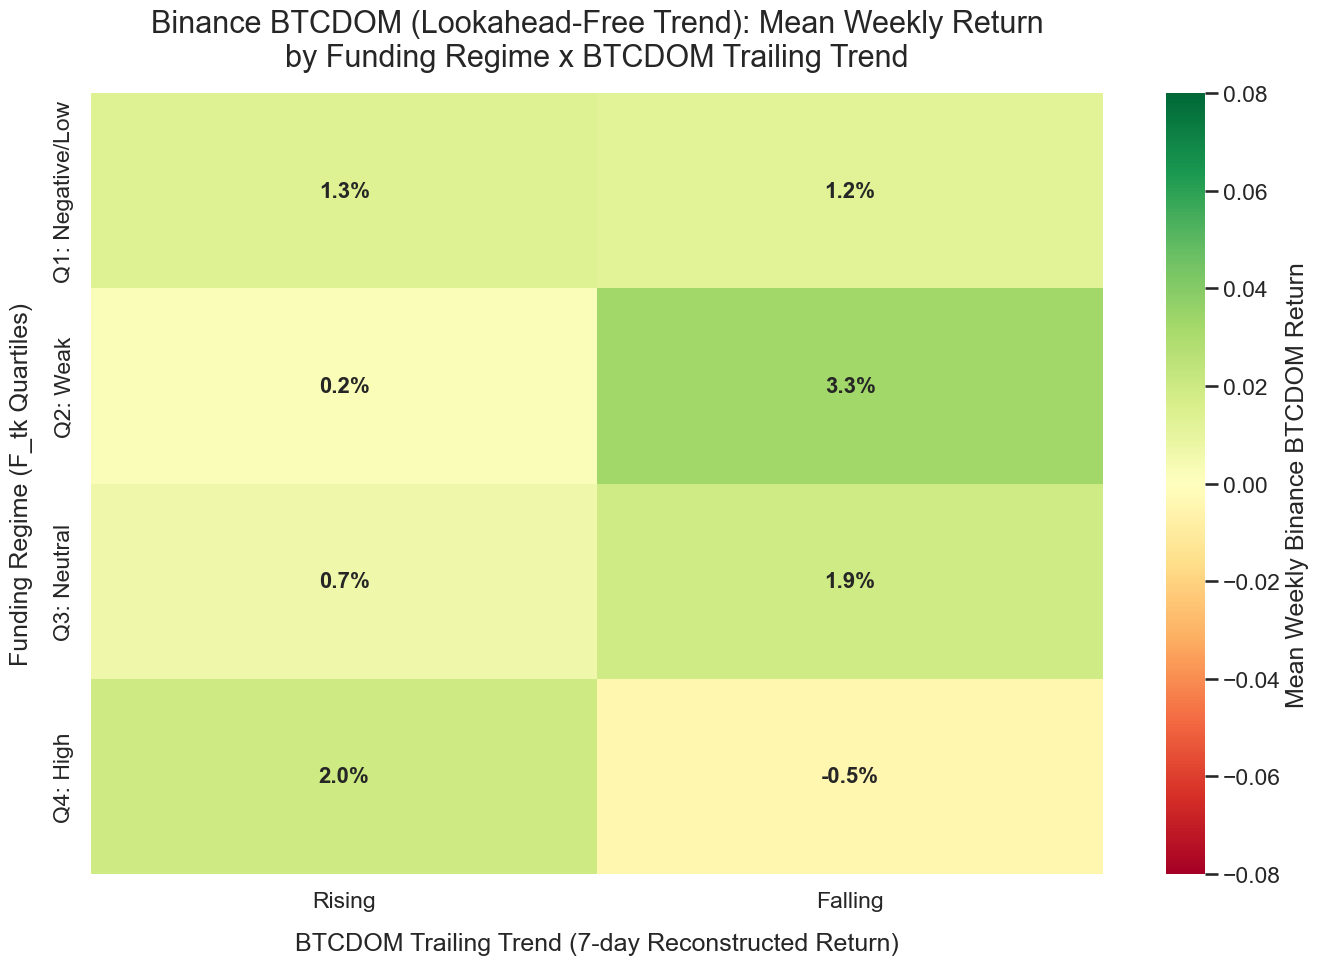

(WindowsPath('C:/Users/Admin/Documents/Cursor/notebooks/matrix_recon_btcdom.png'),
 WindowsPath('C:/Users/Admin/Documents/Cursor/notebooks/matrix_binance_btcdom.png'))

In [14]:
# 11. Trailing-Trend Macro Heatmaps (Lookahead-free trend definition)

# Reload MSM funding + L/S basket
msm_tr = pd.read_csv(
    MSM_TIMESERIES_PATH,
    parse_dates=["decision_date", "next_date"],
)
msm_tr = msm_tr[["decision_date", "next_date", "F_tk", "y"]].copy()
msm_tr["decision_date"] = pd.to_datetime(msm_tr["decision_date"])
msm_tr["next_date"] = pd.to_datetime(msm_tr["next_date"])
msm_tr = msm_tr.sort_values("decision_date").reset_index(drop=True)

# Reconstructed BTCDOM levels
recon_tr = pd.read_csv(
    RECON_BTCDOM_PATH,
    parse_dates=["date"],
).sort_values("date")

recon_levels_tr = recon_tr[["date", "reconstructed_index_value"]].rename(
    columns={"reconstructed_index_value": "recon_index"}
)

# Merge decision and next levels
msm_tr = msm_tr.merge(
    recon_levels_tr.rename(columns={"date": "decision_date", "recon_index": "recon_decision"}),
    on="decision_date",
    how="left",
)
msm_tr = msm_tr.merge(
    recon_levels_tr.rename(columns={"date": "next_date", "recon_index": "recon_next"}),
    on="next_date",
    how="left",
)

# Forward weekly reconstructed return (for values)
msm_tr["ret_btcdom_recon"] = msm_tr["recon_next"] / msm_tr["recon_decision"] - 1.0

# Trailing 7-day reconstructed return (for trend)
msm_tr["trailing_date"] = msm_tr["decision_date"] - pd.Timedelta(days=7)
msm_tr = msm_tr.merge(
    recon_levels_tr.rename(columns={"date": "trailing_date", "recon_index": "recon_trailing"}),
    on="trailing_date",
    how="left",
)
msm_tr["ret_btcdom_trailing"] = msm_tr["recon_decision"] / msm_tr["recon_trailing"] - 1.0

# Binance BTCDOM weekly return (forward)
BINANCE_CURATED_PATH = BASE_DIR / "data" / "curated" / "data_lake" / "binance_btcdom.csv"

binance_tr = pd.read_csv(BINANCE_CURATED_PATH, parse_dates=["timestamp"])
_ts = binance_tr["timestamp"]
if getattr(_ts.dt, "tz", None) is not None:
    binance_tr["timestamp"] = _ts.dt.tz_convert(None)
else:
    binance_tr["timestamp"] = _ts
binance_tr["date"] = binance_tr["timestamp"].dt.normalize()

binance_levels_tr = binance_tr[["date", "close"]].rename(columns={"close": "binance_index"})

msm_tr = msm_tr.merge(
    binance_levels_tr.rename(columns={"date": "decision_date", "binance_index": "binance_decision"}),
    on="decision_date",
    how="left",
)
msm_tr = msm_tr.merge(
    binance_levels_tr.rename(columns={"date": "next_date", "binance_index": "binance_next"}),
    on="next_date",
    how="left",
)

msm_tr["ret_btcdom_binance"] = msm_tr["binance_next"] / msm_tr["binance_decision"] - 1.0

# Drop rows with all key returns available
macro_tr = msm_tr.dropna(
    subset=["F_tk", "ret_btcdom_recon", "ret_btcdom_binance", "ret_btcdom_trailing"],
).copy()

# Funding regime
macro_tr["funding_regime"] = pd.qcut(
    macro_tr["F_tk"],
    q=4,
    labels=["Q1: Negative/Low", "Q2: Weak", "Q3: Neutral", "Q4: High"],
)

# Lookahead-free BTCDOM trend from trailing return
macro_tr["BTCDOM_Trend"] = np.where(macro_tr["ret_btcdom_trailing"] > 0, "Rising", "Falling")
macro_tr["BTCDOM_Trend"] = pd.Categorical(
    macro_tr["BTCDOM_Trend"],
    categories=["Rising", "Falling"],
    ordered=True,
)

macro_group_tr = macro_tr.groupby(["funding_regime", "BTCDOM_Trend"])

recon_macro_stats_tr = macro_group_tr["ret_btcdom_recon"].agg(["count", "mean", "median"]).rename(
    columns={"mean": "mean_ret", "median": "median_ret"}
)
recon_macro_stats_tr["win_rate"] = macro_group_tr["ret_btcdom_recon"].apply(lambda s: (s > 0).mean())
recon_macro_stats_tr["skew"] = macro_group_tr["ret_btcdom_recon"].skew()

binance_macro_stats_tr = macro_group_tr["ret_btcdom_binance"].agg(["count", "mean", "median"]).rename(
    columns={"mean": "mean_ret", "median": "median_ret"}
)
binance_macro_stats_tr["win_rate"] = macro_group_tr["ret_btcdom_binance"].apply(lambda s: (s > 0).mean())
binance_macro_stats_tr["skew"] = macro_group_tr["ret_btcdom_binance"].skew()

# Pivot tables
recon_mean_pivot_tr = recon_macro_stats_tr["mean_ret"].unstack("BTCDOM_Trend")
binance_mean_pivot_tr = binance_macro_stats_tr["mean_ret"].unstack("BTCDOM_Trend")

# Shared styling
sns.set_context("talk")

# Reconstructed BTCDOM heatmap (lookahead-free trend)
plt.figure(figsize=(14, 10))
ax1 = sns.heatmap(
    recon_mean_pivot_tr,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0.0,
    vmin=-0.08,
    vmax=0.08,
    annot_kws={"size": 16, "fontweight": "bold"},
    cbar_kws={"label": "Mean Weekly Reconstructed BTCDOM Return"},
)
plt.title(
    "Reconstructed BTCDOM (Lookahead-Free Trend): Mean Weekly Return\nby Funding Regime x BTCDOM Trailing Trend",
    fontsize=22,
    pad=20,
)
ax1.set_xlabel("BTCDOM Trailing Trend (7-day Reconstructed Return)", fontsize=18, labelpad=15)
ax1.set_ylabel("Funding Regime (F_tk Quartiles)", fontsize=18, labelpad=15)
plt.tight_layout()

recon_heatmap_path = BASE_DIR / "notebooks" / "matrix_recon_btcdom.png"
plt.savefig(recon_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

# Binance BTCDOM heatmap (lookahead-free trend)
plt.figure(figsize=(14, 10))
ax2 = sns.heatmap(
    binance_mean_pivot_tr,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0.0,
    vmin=-0.08,
    vmax=0.08,
    annot_kws={"size": 16, "fontweight": "bold"},
    cbar_kws={"label": "Mean Weekly Binance BTCDOM Return"},
)
plt.title(
    "Binance BTCDOM (Lookahead-Free Trend): Mean Weekly Return\nby Funding Regime x BTCDOM Trailing Trend",
    fontsize=22,
    pad=20,
)
ax2.set_xlabel("BTCDOM Trailing Trend (7-day Reconstructed Return)", fontsize=18, labelpad=15)
ax2.set_ylabel("Funding Regime (F_tk Quartiles)", fontsize=18, labelpad=15)
plt.tight_layout()

binance_heatmap_path = BASE_DIR / "notebooks" / "matrix_binance_btcdom.png"
plt.savefig(binance_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

recon_heatmap_path, binance_heatmap_path